In [1]:
import os

os.chdir("../")

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from statannotations.Annotator import Annotator

from src._config import CLUSTER_NAMES, IMG_DIR, PALETTE

FIG3_DIR = Path(IMG_DIR) / "fig3"
FIG3_DIR.mkdir(parents=True, exist_ok=True)

# Cluster metadata
CLUSTER_ORDER = list(CLUSTER_NAMES.keys())

# Physiology block order and display labels
HR_COLS = ["HR_Pre", "HR_Op1T1", "HR_Op1T2", "HR_Op2T1", "HR_Op2T2"]
BLOCK_LABELS = ["Pre", "1.1", "1.2", "2.1", "2.2"]

## Load data (cohort A)

In [4]:
# Load behavioral features (with cluster labels) from fig2
behav = pd.read_csv("data/processed/behav_Xa.csv", index_col=0)

# Load physiology data
physio = pd.read_excel("data/cohort_a/physPerformance.xlsx", index_col="Subject")

# Clean: subjects with complete HR + HRV across all blocks
hrv_feats = [
    "SDNN",
    "RMSSD",
    "pnn50",
    "SD1",
    "SD2",
    "SD1SD2",
    "ac",
    "dc",
    "rrHRV",
    "lf",
    "hf",
    "lfhf",
    "ttlpwr",
    "SampEn",
    "ApEn",
    "TINN",
    "TRI",
]
all_blocks = ["Pre", "Op1T1", "Op1T2", "Op2T1", "Op2T2"]
cardiac_cols = [f"HR_{b}" for b in all_blocks] + [
    f"{f}_{b}" for f in hrv_feats for b in all_blocks if f"{f}_{b}" in physio.columns
]

shared_subjects = behav.index.intersection(physio.index)
physio_hr = physio.loc[shared_subjects, cardiac_cols].dropna()
labels = behav.loc[physio_hr.index, "label"]

print(f"Subjects with complete HR + HRV: {len(physio_hr)}")

Subjects with complete HR + HRV: 112


In [5]:
# Reshape to long format for plotting
hr_long = physio_hr.copy()
hr_long["label"] = labels
hr_long = hr_long.melt(
    id_vars="label", value_vars=HR_COLS, var_name="block", value_name="HR"
)
hr_long["block"] = pd.Categorical(
    hr_long["block"].map(dict(zip(HR_COLS, BLOCK_LABELS))),
    categories=BLOCK_LABELS,
    ordered=True,
)
hr_long["Cluster"] = hr_long["label"].map(CLUSTER_NAMES)

hr_long.head()

,label,block,HR,Cluster
0,1,Pre,70.122987,Proactive
1,1,Pre,76.507556,Proactive
2,1,Pre,86.350768,Proactive
3,2,Pre,82.146548,Non-aggressive
4,2,Pre,79.809746,Non-aggressive


In [6]:
# Export delta-HR (change from Pre) in long format for brms
delta_hr = physio_hr[HR_COLS[1:]].sub(physio_hr["HR_Pre"], axis=0)
delta_hr["subject"] = delta_hr.index
delta_hr["Cluster"] = labels.map(CLUSTER_NAMES).values

delta_hr_long = delta_hr.melt(
    id_vars=["subject", "Cluster"],
    value_vars=HR_COLS[1:],
    var_name="block",
    value_name="delta_hr",
)
delta_hr_long["block"] = delta_hr_long["block"].map(dict(zip(HR_COLS[1:], BLOCK_LABELS[1:])))

delta_hr_long.to_csv("data/processed/delta_hr_long.csv", index=False)
print(f"Saved {len(delta_hr_long)} rows to data/processed/delta_hr_long.csv")
delta_hr_long.head()

Saved 448 rows to data/processed/delta_hr_long.csv


,subject,Cluster,block,delta_hr
0,P035,Proactive,1.1,5.319939
1,P036,Proactive,1.1,7.885217
2,P042,Proactive,1.1,18.955404
3,P043,Non-aggressive,1.1,9.670495
4,P045,Non-aggressive,1.1,0.895376


In [19]:
# Compute delta-HR (block 1.1 - Pre) for both cohorts
delta1_a = physio_hr.loc[:, "HR_Op1T1"] - physio_hr.loc[:, "HR_Pre"]
delta1_a = pd.DataFrame({"delta_hr": delta1_a, "label": labels, "cohort": "A"})

## Load data (cohort B)

In [20]:
# Load Cohort B: behavioral clusters + physiology
behav_b = pd.read_csv("data/processed/behav_Xb.csv", index_col=0)
physio_b = pd.read_excel("data/cohort_b/physPerformance.xlsx", index_col="Subject")

shared_b = behav_b.index.intersection(physio_b.index)
physio_hr_b = physio_b.loc[shared_b, HR_COLS].dropna()
labels_b = behav_b.loc[physio_hr_b.index, "label"]

print(f"Cohort B — Subjects with HR + cluster labels: {len(physio_hr_b)}")
print(f"Per cluster: {labels_b.map(CLUSTER_NAMES).value_counts().to_dict()}")

# CONSORT flow (Cohort B)
hrv_cols_b = [
    f"{f}_{b}" for f in hrv_feats for b in all_blocks if f"{f}_{b}" in physio_b.columns
]
hr_hrv_b = physio_b.loc[shared_b, [f"HR_{b}" for b in all_blocks] + hrv_cols_b].dropna()
missing_hrv_b = physio_hr_b.index.difference(hr_hrv_b.index)
print(
    f"Missing HRV (have HR): {len(missing_hrv_b)} {sorted(missing_hrv_b) if len(missing_hrv_b) > 0 else ''}"
)
print(f"HR+HRV complete: {len(hr_hrv_b)}")

Cohort B — Subjects with HR + cluster labels: 37
Per cluster: {'Proactive': 19, 'Non-aggressive': 11, 'Reactive': 7}
Missing HRV (have HR): 1 ['BF042']
HR+HRV complete: 36


In [23]:
delta1_b = physio_hr_b.loc[:, "HR_Op1T1"] - physio_hr_b.loc[:, "HR_Pre"]
delta1_b = pd.DataFrame({"delta_hr": delta1_b, "label": labels_b, "cohort": "B"})

delta1 = pd.concat([delta1_a, delta1_b], ignore_index=True)
delta1["Cluster"] = delta1["label"].map(CLUSTER_NAMES)

print(delta1.groupby(["cohort", "Cluster"])["delta_hr"].describe().round(2))

                       count  mean    std   min   25%   50%    75%    max
cohort Cluster                                                           
A      Non-aggressive   36.0  5.68   5.03 -1.15  1.24  5.18   9.49  18.53
       Proactive        52.0  5.63   8.87 -7.05  0.43  3.78   8.14  38.86
       Reactive         24.0  9.88   7.00 -2.17  4.76  8.46  13.79  22.50
B      Non-aggressive   11.0  4.32   5.52 -2.88 -0.28  3.47   8.97  12.27
       Proactive        19.0  4.19  10.43 -8.34 -1.26  2.36   6.96  38.41
       Reactive          7.0  6.96   3.66  2.25  4.68  5.42   9.67  12.33


In [8]:
# Export Cohort B delta-HR long format for brms replication
delta_hr_b = physio_hr_b[HR_COLS[1:]].sub(physio_hr_b["HR_Pre"], axis=0)
delta_hr_b["subject"] = delta_hr_b.index
delta_hr_b["Cluster"] = labels_b.map(CLUSTER_NAMES).values

delta_hr_long_b = delta_hr_b.melt(
    id_vars=["subject", "Cluster"],
    value_vars=HR_COLS[1:],
    var_name="block",
    value_name="delta_hr",
)
delta_hr_long_b["block"] = delta_hr_long_b["block"].map(
    dict(zip(HR_COLS[1:], BLOCK_LABELS[1:]))
)

delta_hr_long_b.to_csv("data/processed/delta_hr_long_b.csv", index=False)
print(f"Saved {len(delta_hr_long_b)} rows to data/processed/delta_hr_long_b.csv")

Saved 148 rows to data/processed/delta_hr_long_b.csv


## Delta-HR by cluster × block (barplot with 95% CrI + BF annotations)

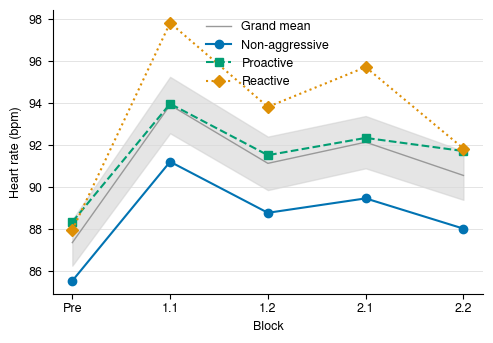

In [9]:
# Fig 3a: HR time course by cluster across experimental blocks (mean ± SEM)
palette = sns.color_palette("colorblind", n_colors=3)
cluster_colors = {CLUSTER_NAMES[k]: v for k, v in PALETTE.items()}
# → {'Reactive': '#de8f05', 'Proactive': '#029e73', 'Non-aggressive': '#0173b2'}

# Compute mean and SEM per cluster × block
hr_stats = (
    hr_long.groupby(["label", "block"], observed=True)["HR"]
    .agg(["mean", "sem"])
    .reset_index()
)
hr_stats["Cluster"] = hr_stats["label"].map(CLUSTER_NAMES)

# Grand mean ± SEM (across all subjects, ignoring cluster)
grand_stats = hr_long.groupby("block", observed=True)["HR"].agg(["mean", "sem"])

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    # Horizontal grid lines
    ax.grid(which="major", axis="y", color="0.85", linewidth=0.5)
    ax.set_axisbelow(True)

    x = np.arange(len(BLOCK_LABELS))
    markers = ["o", "s", "D"]
    linestyles = ["-", "--", ":"]

    # Grand mean with SEM shading
    gm = grand_stats["mean"].values
    gsem = grand_stats["sem"].values
    ax.fill_between(x, gm - gsem, gm + gsem, color="0.8", alpha=0.5, zorder=0)
    ax.plot(x, gm, color="0.6", linestyle="-", linewidth=1, zorder=1, label="Grand mean")

    # Per-cluster lines
    for i, c in enumerate(CLUSTER_ORDER):
        mask = hr_stats["label"] == c
        mean = hr_stats.loc[mask, "mean"].values
        name = CLUSTER_NAMES[c]
        color = cluster_colors[name]

        ax.plot(
            x, mean,
            color=color, marker=markers[i], linestyle=linestyles[i],
            label=name, markersize=6, linewidth=1.5, zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(BLOCK_LABELS)
    ax.set_xlabel("Block")
    ax.set_ylabel("Heart rate (bpm)")
    ax.legend(title="", frameon=False)

    fig.tight_layout()
    fig.savefig(FIG3_DIR / "hr_timecourse.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "hr_timecourse.png", dpi=300, bbox_inches="tight")
    plt.show()

## BRMs posterior draws for delta HR

In [37]:
# Load brms posterior draws and BFs for delta-HR
delta_hr_posterior = pd.read_csv("data/brms/delta_hr/posterior_epred.csv").drop(
    columns=[".row", ".draw"]
)
bf_delta_hr = pd.read_csv("data/brms/delta_hr/bayes_factors.csv")

print(delta_hr_posterior.groupby(["block", "Cluster"])["delta_hr"].describe().round(2).to_markdown())
print()
print(bf_delta_hr[["block", "contrast", "BF10", "excl_zero"]].to_markdown())

|                         |   count |   mean |   std |   min |   25% |   50% |   75% |   max |
|:------------------------|--------:|-------:|------:|------:|------:|------:|------:|------:|
| (1.1, 'Non-aggressive') |   16000 |   5.42 |  0.82 |  2.17 |  4.88 |  5.42 |  5.97 |  8.95 |
| (1.1, 'Proactive')      |   16000 |   3.81 |  0.71 |  1.06 |  3.34 |  3.8  |  4.28 |  6.7  |
| (1.1, 'Reactive')       |   16000 |  10.1  |  1.12 |  5.73 |  9.34 | 10.1  | 10.86 | 14.64 |
| (1.2, 'Non-aggressive') |   16000 |   3.29 |  0.78 |  0.38 |  2.78 |  3.28 |  3.81 |  6.6  |
| (1.2, 'Proactive')      |   16000 |   2.76 |  0.65 |  0.07 |  2.32 |  2.76 |  3.2  |  5.27 |
| (1.2, 'Reactive')       |   16000 |   5.5  |  0.97 |  1.39 |  4.86 |  5.49 |  6.15 |  9.56 |
| (2.1, 'Non-aggressive') |   16000 |   3.83 |  0.79 |  0.77 |  3.29 |  3.82 |  4.34 |  7.01 |
| (2.1, 'Proactive')      |   16000 |   3.62 |  0.65 |  1.16 |  3.19 |  3.62 |  4.05 |  6.22 |
| (2.1, 'Reactive')       |   16000 |   7.66 |  0.

In [28]:
# Parse significant contrasts for annotation
BF_THRESHOLD = 10**0.5

def parse_contrast(c):
    """'(Non-aggressive) - Proactive' -> ('Non-aggressive', 'Proactive')"""
    parts = c.split(" - ")
    return parts[0].strip("() "), parts[1].strip("() ")

sig = bf_delta_hr[(bf_delta_hr["excl_zero"]) & (bf_delta_hr["BF10"] >= BF_THRESHOLD)]

sig_contrasts_hr = {}
for block in bf_delta_hr["block"].unique():
    block_sig = sig[sig["block"] == block]
    sig_contrasts_hr[block] = []
    for _, row in block_sig.iterrows():
        c1, c2 = parse_contrast(row["contrast"])
        bf = row["BF10"]
        label = "BF > 100" if bf > 100 else f"BF = {bf:.1f}"
        sig_contrasts_hr[block].append((c1, c2, label))

sig_contrasts_hr

{np.float64(1.1): [('Non-aggressive', 'Reactive', 'BF = 63.3'),
  ('Proactive', 'Reactive', 'BF > 100')],
 np.float64(1.2): [],
 np.float64(2.1): [('Non-aggressive', 'Reactive', 'BF = 18.7'),
  ('Proactive', 'Reactive', 'BF = 34.5')],
 np.float64(2.2): []}

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

2.1_Non-aggressive vs. 2.1_Reactive: BF = 18.7
2.1_Reactive vs. 2.1_Proactive: BF = 34.5
1.1_Non-aggressive vs. 1.1_Reactive: BF = 63.3
1.1_Reactive vs. 1.1_Proactive: BF > 100


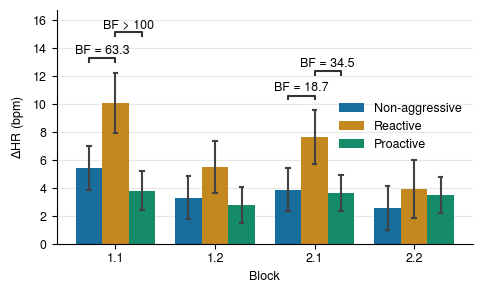

In [29]:
# Fig 3b: Delta-HR by cluster × block (barplot with 95% CrI + BF annotations)
cluster_hue_order = ["Non-aggressive", "Reactive", "Proactive"]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3))

    sns.barplot(
        data=delta_hr_posterior,
        x="block",
        y="delta_hr",
        hue="Cluster",
        hue_order=cluster_hue_order,
        palette=cluster_colors,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )

    ax.set_xlabel("Block")
    ax.set_ylabel(r"$\Delta$HR (bpm)")
    ax.legend(title="", frameon=False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    pairs = []
    custom_annots = []
    for block in sig_contrasts_hr:
        for c1, c2, bf_label in sig_contrasts_hr[block]:
            pairs.append(((block, c1), (block, c2)))
            custom_annots.append(bf_label)

    if pairs:
        annot = Annotator(
            ax,
            pairs,
            data=delta_hr_posterior,
            x="block",
            y="delta_hr",
            hue="Cluster",
            hue_order=cluster_hue_order,
        )
        annot.set_custom_annotations(custom_annots)
        annot.annotate()

    fig.tight_layout()
    fig.savefig(FIG3_DIR / "delta_hr_by_block.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "delta_hr_by_block.png", dpi=300, bbox_inches="tight")
    plt.show()

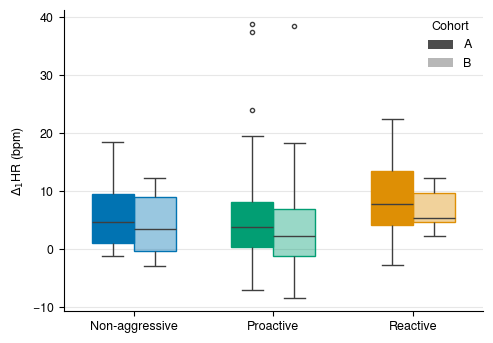

In [64]:
# Fig 3c: Delta1-HR by cluster, Cohort A vs Cohort B (split violin)
cluster_hue_order = ["Non-aggressive", "Proactive", "Reactive"]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    sns.boxplot(
        data=delta1,
        x="Cluster",
        y="delta_hr",
        hue="cohort",
        order=cluster_hue_order,
        hue_order=["A", "B"],
        width=0.6,
        fliersize=3,
        ax=ax,
    )

    # Recolor: cluster colors, with alpha=0.4 for Cohort B
    from matplotlib.colors import to_rgba

    colors = [cluster_colors[c] for c in cluster_hue_order]
    for i, patch in enumerate(ax.patches):
        cluster_idx = i % len(colors)
        hue_idx = i // len(colors)
        c = colors[cluster_idx]
        alpha = 1.0 if hue_idx == 0 else 0.4
        patch.set_facecolor(to_rgba(c, alpha))
        patch.set_edgecolor(c)

    from matplotlib.patches import Patch

    legend_handles = [
        Patch(facecolor="0.3", label="A"),
        Patch(facecolor="0.3", alpha=0.4, label="B"),
    ]
    ax.legend(handles=legend_handles, title="Cohort", frameon=False)

    ax.set_xlabel("")
    ax.set_ylabel(r"$\Delta_1$HR (bpm)")
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)
    # ax.legend(title="Cohort", frameon=False)

    fig.tight_layout()
    fig.savefig(FIG3_DIR / "delta1_hr_cohorts.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "delta1_hr_cohorts.png", dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
# Prepare multivariate physio data for brms
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Domain definitions
hrv_feats = [
    "SDNN",
    "RMSSD",
    "pnn50",
    "SD1",
    "SD2",
    "SD1SD2",
    "ac",
    "dc",
    "rrHRV",
    "lf",
    "hf",
    "lfhf",
    "ttlpwr",
    "SampEn",
    "ApEn",
    "TINN",
    "TRI",
]
resp_feats = ["RespRate", "RespDepth", "RespWidth", "RespRatio"]
eda_feats = ["nSCRcda", "nSCRttp", "AmpSumttp", "Toniccda"]

FEATURES_TO_REMOVE = ("AmpSumcda", "ulf", "vlf")
cols_keep = [
    c
    for c in physio.columns
    if not c.startswith(FEATURES_TO_REMOVE) and not c.endswith("_Post")
]
physio_clean = physio.loc[physio_hr.index, cols_keep].dropna()
labels_clean = behav.loc[physio_clean.index, "Cluster"]

blocks_delta = ["Op1T1", "Op1T2", "Op2T1", "Op2T2"]

rows = []
for subj in physio_clean.index:
    for blk, blk_label in zip(blocks_delta, BLOCK_LABELS[1:]):
        row = {
            "subject": subj,
            "Cluster": labels_clean[subj],
            "block": blk_label,
            "HR": physio_clean.loc[subj, f"HR_{blk}"]
            - physio_clean.loc[subj, "HR_Pre"],
            "RespRate": physio_clean.loc[subj, f"RespRate_{blk}"]
            - physio_clean.loc[subj, "RespRate_Pre"],
            "nSCRcda": physio_clean.loc[subj, f"nSCRcda_{blk}"]
            - physio_clean.loc[subj, "nSCRcda_Pre"],
        }
        rows.append(row)

df_mv = pd.DataFrame(rows)

# Within-domain PC1 scores per block
for domain_name, domain_feats in [
    ("HRV_PC1", hrv_feats),
    ("Resp_PC1", resp_feats),
    ("EDA_PC1", eda_feats),
]:
    for blk, blk_label in zip(blocks_delta, BLOCK_LABELS[1:]):
        available = [
            f
            for f in domain_feats
            if f"{f}_Pre" in physio_clean.columns
            and f"{f}_{blk}" in physio_clean.columns
        ]
        deltas = pd.DataFrame(
            {
                f: physio_clean[f"{f}_{blk}"] - physio_clean[f"{f}_Pre"]
                for f in available
            }
        )
        X_scaled = StandardScaler().fit_transform(deltas)
        pc1_scores = (
            PCA(n_components=1, random_state=42).fit_transform(X_scaled).ravel()
        )

        mask = df_mv["block"] == blk_label
        df_mv.loc[mask, domain_name] = pc1_scores

df_mv.to_csv("data/processed/physio_multivariate_long.csv", index=False)
print(f"Saved {df_mv.shape} to data/processed/physio_multivariate_long.csv")
print(df_mv.head(8))

Saved (432, 9) to data/processed/physio_multivariate_long.csv
  subject    Cluster block         HR  RespRate   nSCRcda   HRV_PC1  Resp_PC1  \
0    P035  Proactive   1.1   5.319939  5.134957  2.800187 -1.796393  1.793472   
1    P035  Proactive   1.2   0.886272  6.286187  5.200347 -5.866669  0.684822   
2    P035  Proactive   2.1   3.686231  5.336519 -5.600373 -1.181002  0.746378   
3    P035  Proactive   2.2   2.430353  4.360576 -6.000400 -4.331949  1.749223   
4    P036  Proactive   1.1   7.885217 -1.421371  7.200480 -1.041939  4.576429   
5    P036  Proactive   1.2   9.464060 -0.486891  4.000267 -2.406011  4.558690   
6    P036  Proactive   2.1  11.507287  0.316132  4.000267 -2.172605  3.713193   
7    P036  Proactive   2.2  12.825290  2.032099  7.600507 -3.476746  2.451334   

    EDA_PC1  
0 -0.106531  
1 -0.009462  
2 -1.004434  
3 -1.190525  
4  0.262931  
5 -0.037977  
6  1.203798  
7  0.980401  


## Supplementary: baseline HR

In [14]:
# Export baseline HR for brms
baseline_hr = pd.DataFrame(
    {
        "subject": physio_hr.index,
        "HR_Pre": physio.loc[physio_hr.index, "HR_Pre"].values,
        "Cluster": behav.loc[physio_hr.index, "Cluster"].values,
    }
)
baseline_hr.to_csv("data/processed/baseline_hr.csv", index=False)
print(f"Saved {len(baseline_hr)} rows to data/processed/baseline_hr.csv")
print(baseline_hr.groupby("Cluster")["HR_Pre"].describe().round(2))

Saved 112 rows to data/processed/baseline_hr.csv
                count   mean    std    min    25%    50%    75%     max
Cluster                                                                
Non-aggressive   36.0  85.51  10.89  63.01  77.75  85.99  92.67  111.20
Proactive        52.0  88.32  12.48  65.24  80.54  86.15  95.87  116.38
Reactive         24.0  87.92  10.83  72.51  77.69  89.23  96.77  111.33


/tmp/ipykernel_2079974/2110992199.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


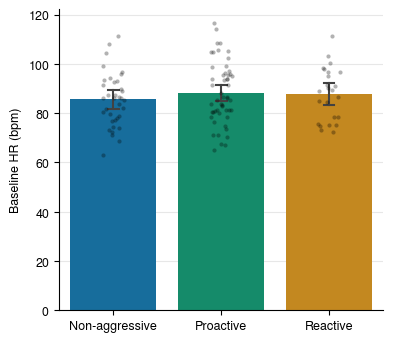

In [26]:
# S19: Baseline HR by cluster — posterior predicted means with CrIs
baseline_posterior = pd.read_csv("data/brms/baseline_hr/posterior_epred.csv").drop(
    columns=[".row", ".draw"], errors="ignore"
)

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(4, 3.5))

    cluster_hue_order = ["Non-aggressive", "Proactive", "Reactive"]

    sns.barplot(
        data=baseline_posterior,
        x="Cluster",
        y="HR_Pre",
        order=cluster_hue_order,
        palette=cluster_colors,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )
    sns.stripplot(
        data=baseline_hr,
        x="Cluster",
        y="HR_Pre",
        order=cluster_hue_order,
        color="k",
        size=3,
        alpha=0.3,
        jitter=True,
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Baseline HR (bpm)")
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    fig.tight_layout()
    fig.savefig(FIG3_DIR / "baseline_hr.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "baseline_hr.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: Cardiac model contrasts (HR + HRV PC1-3)

In [15]:
# Export cardiac data for brms (HR + HRV PC1-3)
hrv_feats = [
    "SDNN",
    "RMSSD",
    "pnn50",
    "SD1",
    "SD2",
    "SD1SD2",
    "ac",
    "dc",
    "rrHRV",
    "lf",
    "hf",
    "lfhf",
    "ttlpwr",
    "SampEn",
    "ApEn",
    "TINN",
    "TRI",
]

FEATURES_TO_REMOVE = ("AmpSumcda", "ulf", "vlf")
cols_keep = [
    c
    for c in physio.columns
    if not c.startswith(FEATURES_TO_REMOVE) and not c.endswith("_Post")
]
physio_clean = physio.loc[physio_hr.index, cols_keep].dropna()
labels_clean = behav.loc[physio_clean.index, "Cluster"]

blocks_delta = ["Op1T1", "Op1T2", "Op2T1", "Op2T2"]

rows = []
for subj in physio_clean.index:
    for blk, blk_label in zip(blocks_delta, BLOCK_LABELS[1:]):
        rows.append(
            {
                "subject": subj,
                "Cluster": labels_clean[subj],
                "block": blk_label,
                "HR": physio_clean.loc[subj, f"HR_{blk}"]
                - physio_clean.loc[subj, "HR_Pre"],
            }
        )

df_cardiac = pd.DataFrame(rows)

# HRV PC1-3 per block
for blk, blk_label in zip(blocks_delta, BLOCK_LABELS[1:]):
    available = [
        f
        for f in hrv_feats
        if f"{f}_Pre" in physio_clean.columns and f"{f}_{blk}" in physio_clean.columns
    ]
    deltas = pd.DataFrame(
        {f: physio_clean[f"{f}_{blk}"] - physio_clean[f"{f}_Pre"] for f in available}
    )
    X_scaled = StandardScaler().fit_transform(deltas)
    pca_hrv = PCA(n_components=3, random_state=42)
    scores = pca_hrv.fit_transform(X_scaled)

    mask = df_cardiac["block"] == blk_label
    df_cardiac.loc[mask, "HRV_PC1"] = scores[:, 0]
    df_cardiac.loc[mask, "HRV_PC2"] = scores[:, 1]
    df_cardiac.loc[mask, "HRV_PC3"] = scores[:, 2]

df_cardiac.to_csv("data/processed/physio_cardiac_long.csv", index=False)
print(f"Saved {df_cardiac.shape} to data/processed/physio_cardiac_long.csv")

# Print what each PC captures (block 1.1 as example)
cumvar = np.cumsum(pca_hrv.explained_variance_ratio_)
for i in range(3):
    print(f"PC{i+1}: {pca_hrv.explained_variance_ratio_[i]:.1%} (cum: {cumvar[i]:.1%})")

Saved (432, 7) to data/processed/physio_cardiac_long.csv
PC1: 47.1% (cum: 47.1%)
PC2: 17.5% (cum: 64.5%)
PC3: 12.3% (cum: 76.8%)


Contrasts with CrI excluding zero:
DV  block                    contrast  estimate  lower.HPD  upper.HPD
HR    1.1 (Non-aggressive) - Reactive -3.452767  -6.159198  -0.786268
HR    1.1        Proactive - Reactive -5.183937  -7.855893  -2.584144
HR    1.2        Proactive - Reactive -2.589492  -5.016319  -0.218105
HR    2.1 (Non-aggressive) - Reactive -3.703876  -6.159428  -1.180660
HR    2.1        Proactive - Reactive -3.918092  -6.309955  -1.426703


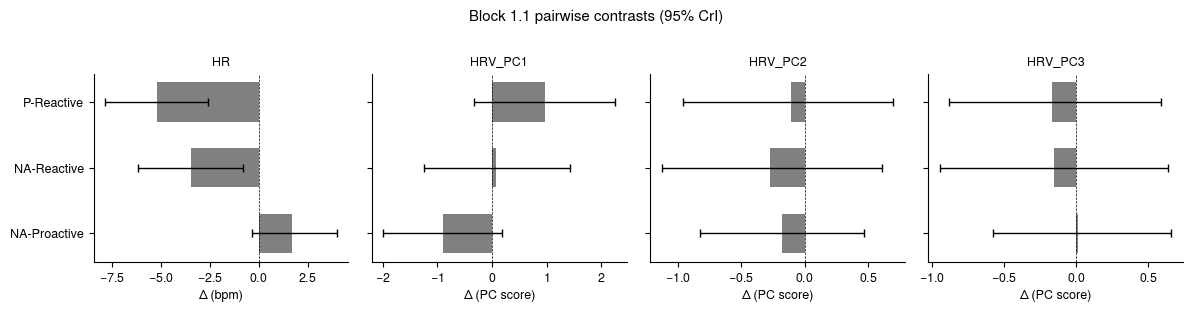

In [16]:
cardiac_contrasts = pd.read_csv("data/brms/physio_cardiac/pairwise_contrasts.csv")

# Filter to CrIs that exclude zero
sig = cardiac_contrasts[
    (cardiac_contrasts["lower.HPD"] > 0) | (cardiac_contrasts["upper.HPD"] < 0)
]
print("Contrasts with CrI excluding zero:")
print(
    sig[["DV", "block", "contrast", "estimate", "lower.HPD", "upper.HPD"]].to_string(
        index=False
    )
)

# Plot: per-DV estimated contrasts at block 1.1
dv_order = ["HR", "HRV_PC1", "HRV_PC2", "HRV_PC3"]
block11 = cardiac_contrasts[cardiac_contrasts["block"] == 1.1]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

    for ax, dv in zip(axes, dv_order):
        sub = block11[block11["DV"] == dv]
        y = range(len(sub))
        ax.barh(
            y,
            sub["estimate"],
            xerr=[
                sub["estimate"] - sub["lower.HPD"],
                sub["upper.HPD"] - sub["estimate"],
            ],
            color="0.5",
            capsize=3,
            height=0.6,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(
            [
                c.replace("(Non-aggressive) - ", "NA-").replace("Proactive - ", "P-")
                for c in sub["contrast"]
            ]
        )
        ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
        ax.set_title(dv)
        ax.set_xlabel("Δ (bpm)" if dv == "HR" else "Δ (PC score)")

    fig.suptitle("Block 1.1 pairwise contrasts (95% CrI)", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG3_DIR / "cardiac_contrasts.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "cardiac_contrasts.png", dpi=300, bbox_inches="tight")
    plt.show()

In [17]:
# Export cardiac data with varimax-rotated HRV components
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def varimax(Phi, max_iter=100, tol=1e-6):
    """Varimax rotation on a loadings matrix (n_features x n_components)."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(max_iter):
        d_old = d
        Lambda = Phi @ R
        u, s, vt = np.linalg.svd(
            Phi.T
            @ (Lambda**3 - (Lambda * np.sum(Lambda**2, axis=0, keepdims=True)) / p)
        )
        R = u @ vt
        d = np.sum(s)
        if d - d_old < tol:
            break
    return Phi @ R


hrv_feats = [
    "SDNN",
    "RMSSD",
    "pnn50",
    "SD1",
    "SD2",
    "SD1SD2",
    "ac",
    "dc",
    "rrHRV",
    "lf",
    "hf",
    "lfhf",
    "ttlpwr",
    "SampEn",
    "ApEn",
    "TINN",
    "TRI",
]

FEATURES_TO_REMOVE = ("AmpSumcda", "ulf", "vlf")
cols_keep = [
    c
    for c in physio.columns
    if not c.startswith(FEATURES_TO_REMOVE) and not c.endswith("_Post")
]
hrv_cols = [f"{f}_{b}" for f in available for b in all_blocks]
hr_cols_all = [f"HR_{b}" for b in all_blocks]
cardiac_cols = hr_cols_all + hrv_cols
physio_clean = physio.loc[physio_hr.index, cardiac_cols].dropna()
labels_clean = behav.loc[physio_clean.index, "Cluster"]

all_blocks = ["Pre", "Op1T1", "Op1T2", "Op2T1", "Op2T2"]
blocks_delta = ["Op1T1", "Op1T2", "Op2T1", "Op2T2"]
available = [
    f for f in hrv_feats if all(f"{f}_{b}" in physio_clean.columns for b in all_blocks)
]

# Fit PCA + varimax on all raw HRV data pooled
all_raw = []
for blk in all_blocks:
    all_raw.append(
        pd.DataFrame({f: physio_clean[f"{f}_{blk}"].values for f in available})
    )
pooled = pd.concat(all_raw, ignore_index=True)

scaler_hrv = StandardScaler().fit(pooled)
pca_hrv = PCA(n_components=3, random_state=42).fit(scaler_hrv.transform(pooled))

loadings = pca_hrv.components_.T * np.sqrt(pca_hrv.explained_variance_)
rotated = varimax(loadings)
rot_var = (rotated**2).sum(axis=0)
order = np.argsort(rot_var)[::-1]
rotated = rotated[:, order]

# Build rotation matrix for projecting new data
R_varimax = np.linalg.lstsq(loadings, rotated, rcond=None)[0]

# Project Pre
pre_raw = pd.DataFrame({f: physio_clean[f"{f}_Pre"].values for f in available})
pre_scores = scaler_hrv.transform(pre_raw) @ pca_hrv.components_.T @ R_varimax

# Build long-format data
rows = []
for subj_idx, subj in enumerate(physio_clean.index):
    for blk, blk_label in zip(blocks_delta, BLOCK_LABELS[1:]):
        rows.append(
            {
                "subject": subj,
                "Cluster": labels_clean[subj],
                "block": blk_label,
                "HR": physio_clean.loc[subj, f"HR_{blk}"]
                - physio_clean.loc[subj, "HR_Pre"],
            }
        )

df_cardiac = pd.DataFrame(rows)

for blk_idx, (blk, blk_label) in enumerate(zip(blocks_delta, BLOCK_LABELS[1:])):
    raw = pd.DataFrame({f: physio_clean[f"{f}_{blk}"].values for f in available})
    blk_scores = scaler_hrv.transform(raw) @ pca_hrv.components_.T @ R_varimax
    delta_scores = blk_scores - pre_scores

    mask = df_cardiac["block"] == blk_label
    df_cardiac.loc[mask, "HRV_RC1"] = delta_scores[:, 0]
    df_cardiac.loc[mask, "HRV_RC2"] = delta_scores[:, 1]
    df_cardiac.loc[mask, "HRV_RC3"] = delta_scores[:, 2]

df_cardiac.to_csv("data/processed/physio_cardiac_long.csv", index=False)
print(f"Saved {df_cardiac.shape}")

# Report what each RC captures
rc_names = ["Overall HRV power", "Vagal/parasympathetic", "Complexity/entropy"]
for i in range(3):
    top_idx = np.argsort(np.abs(rotated[:, i]))[::-1][:4]
    top = ", ".join([f"{available[j]}={rotated[j,i]:+.2f}" for j in top_idx])
    print(f"RC{i+1} ({rc_names[i]}): {top}")

Saved (448, 7)
RC1 (Overall HRV power): SD2=-0.93, SDNN=-0.93, TRI=-0.88, ttlpwr=-0.88
RC2 (Vagal/parasympathetic): SD1SD2=-0.84, hf=-0.72, lfhf=+0.72, RMSSD=-0.71
RC3 (Complexity/entropy): SampEn=+0.92, ApEn=+0.88, rrHRV=+0.49, ac=-0.32


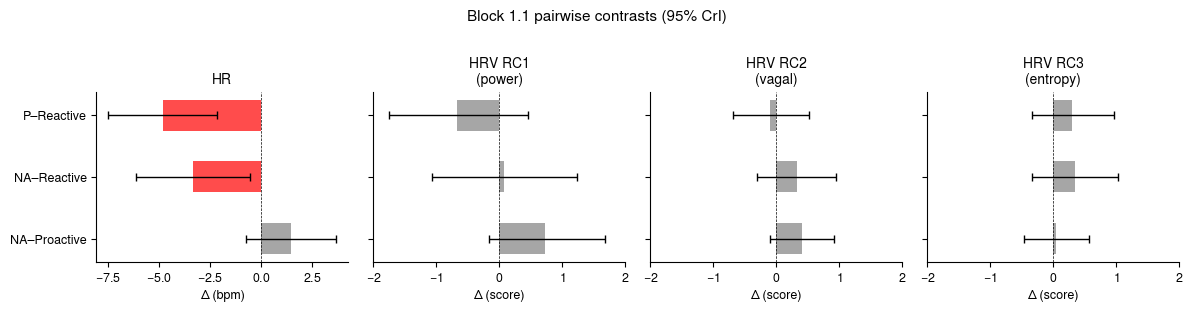

In [32]:
# Supplementary: Cardiac model contrasts (HR + HRV RC1-3)
cardiac_contrasts = pd.read_csv("data/brms/physio_cardiac/pairwise_contrasts.csv")

dv_order = ["HR", "HRV_RC1", "HRV_RC2", "HRV_RC3"]
dv_titles = ["HR", "HRV RC1\n(power)", "HRV RC2\n(vagal)", "HRV RC3\n(entropy)"]

# Focus on block 1.1 (strongest HR effect)
block11 = cardiac_contrasts[cardiac_contrasts["block"] == 1.1]


# Shorten contrast names
def short_contrast(c):
    return c.replace("(Non-aggressive) - ", "NA–").replace("Proactive - ", "P–")


with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

    for ax, dv, title in zip(axes, dv_order, dv_titles):
        sub = block11[block11["DV"] == dv].copy()
        sub["short"] = sub["contrast"].apply(short_contrast)
        y = np.arange(len(sub))

        colors = [
            "red" if (lo > 0 or hi < 0) else "0.5"
            for lo, hi in zip(sub["lower.HPD"], sub["upper.HPD"])
        ]

        ax.barh(
            y,
            sub["estimate"],
            xerr=[
                sub["estimate"] - sub["lower.HPD"],
                sub["upper.HPD"] - sub["estimate"],
            ],
            color=colors,
            capsize=3,
            height=0.5,
            alpha=0.7,
        )
        ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
        ax.set_yticks(y)
        ax.set_yticklabels(sub["short"])
        ax.set_title(title, fontsize=10)

    axes[0].set_xlabel("Δ (bpm)")
    for ax in axes[1:]:
        ax.set_xlabel("Δ (score)")
        ax.set_xlim(-2, 2)

    fig.suptitle("Block 1.1 pairwise contrasts (95% CrI)", y=1.02, fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG3_DIR / "cardiac_contrasts.pdf", bbox_inches="tight")
    fig.savefig(FIG3_DIR / "cardiac_contrasts.png", dpi=300, bbox_inches="tight")
    plt.show()